In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
dt4training = pd.read_csv('training.csv')
dt4tesing = pd.read_csv('testing.csv')

In [ ]:
#create copy of training data
data = dt4training.copy()

#create unique list of names
UniqueCodes = data.loc[:,'Country Code'].unique()

#create a data frame dictionary to store your data frames
DataFrameDict = {elem : pd.DataFrame() for elem in UniqueCodes}

for key in DataFrameDict.keys():
    DataFrameDict[key] = data[:][data.loc[:,'Country Code'] == key]

In [ ]:
display(DataFrameDict['EST'])

,Country Code,Year,Debt_GDP,AnnualInflationPercent,CurrentAccountBalance(USD),ExportToGDP,FDI,GovtExpend,ImportToGDP,LabourForceParticipation,...,NetPopMigrate,PopGrow,WorkAgePop,ProfitTaxToCommercialProfit,UrbanProportion,SocialSpendingToGDP,RealIntRate,TaxRevenueToGDP,TotalLabourForce,UnemploymentRate
9,EST,2010,3.36,2.97,340438472.30,75.05,2592255115.00,7871.00,68.63,37.66,...,-3781.00,-0.23,67.32,8.30,68.09,18.14,NaN,19.82,681602.00,16.71
47,EST,2011,3.29,4.98,304229741.40,86.27,1119148299.00,8688.00,80.48,39.98,...,-3941.00,-0.30,67.00,8.30,67.97,16.18,NaN,19.17,687096.00,12.33
85,EST,2012,10.91,3.93,-431767874.00,85.40,1787341527.00,9034.00,83.76,40.81,...,-3674.00,-0.36,66.55,8.30,67.97,15.75,NaN,19.76,683224.00,10.02
123,EST,2013,11.06,2.78,-33886278.83,83.45,1097942107.00,9651.00,81.15,39.73,...,-2688.00,-0.36,66.06,8.20,68.12,15.68,NaN,19.90,679674.00,8.63
161,EST,2014,11.32,-0.11,140258987.20,80.59,1781648554.00,10058.00,77.36,39.11,...,-674.00,-0.26,65.55,8.20,68.27,15.98,NaN,20.42,674311.00,7.35
199,EST,2015,10.98,-0.49,341116116.00,76.03,-715465129.90,9048.00,72.47,41.82,...,4261.00,0.07,65.10,8.20,68.42,17.28,NaN,21.25,684582.00,6.41
237,EST,2016,10.93,0.15,243657604.20,75.48,925762256.70,9484.00,72.27,43.25,...,1081.00,0.03,64.66,7.80,68.56,17.53,NaN,21.34,691057.00,6.88
275,EST,2017,10.00,3.42,466904437.60,74.31,1735775304.00,10564.00,70.33,46.12,...,5202.00,0.12,64.26,7.80,68.72,17.03,NaN,20.53,700101.00,5.81
313,EST,2018,9.32,3.44,176021223.70,72.90,1273932848.00,12027.00,70.58,47.35,...,7089.00,0.35,63.96,7.80,68.88,17.46,NaN,20.56,703757.00,5.41
351,EST,2019,9.71,2.28,640362558.70,72.02,3113489502.00,12243.00,68.33,44.67,...,5386.00,0.37,63.67,7.70,69.05,17.91,NaN,20.76,703304.00,4.51


In [ ]:
EST_df = DataFrameDict['EST']
EST_df.to_csv('EstoniaData.csv',index=False)

#Inflation Percent

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'AnnualInflationPercent'].reset_index(drop=True)

x = sm.add_constant(x)


model1 = sm.OLS(y,x).fit()

model1.params

,0
const,12.78
AnnualInflationPercent,-1.37


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'AnnualInflationPercent'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
0,8.72
1,5.97
2,7.40
3,8.98
4,12.93
5,13.46
6,12.58
7,8.11
8,8.08
9,9.67


In [ ]:
model1_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','AnnualInflationPercent']].reset_index(drop=True)

model1_assessment['model1_predicted_debt'] = model1.predict(x_test)

model1_assessment['percentage error'] = abs((model1_assessment['Debt_GDP'] - model1_assessment['model1_predicted_debt'])/model1_assessment['Debt_GDP'])

display(model1_assessment)

,Country Code,Year,Debt_GDP,AnnualInflationPercent,model1_predicted_debt,percentage error
0,EST,2010,3.36,2.97,8.72,1.59
1,EST,2011,3.29,4.98,5.97,0.81
2,EST,2012,10.91,3.93,7.40,0.32
3,EST,2013,11.06,2.78,8.98,0.19
4,EST,2014,11.32,-0.11,12.93,0.14
5,EST,2015,10.98,-0.49,13.46,0.23
6,EST,2016,10.93,0.15,12.58,0.15
7,EST,2017,10.00,3.42,8.11,0.19
8,EST,2018,9.32,3.44,8.08,0.13
9,EST,2019,9.71,2.28,9.67,0.00


In [ ]:
AnnualInflationPercent_MAPE = model1_assessment['percentage error'].mean()
display(AnnualInflationPercent_MAPE)

np.float64(0.3666546430705878)

#Current Account Balance (USD)

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'CurrentAccountBalance(USD)'].reset_index(drop=True)

x = sm.add_constant(x)


model2 = sm.OLS(y,x).fit()

model2.params

,0
const,10.68
CurrentAccountBalance(USD),-0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'CurrentAccountBalance(USD)'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model2.predict(x_test)

,0
0,8.56
1,8.79
2,13.37
3,10.89
4,9.81
5,8.56
6,9.16
7,7.77
8,9.59
9,6.69


In [ ]:
model2_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','CurrentAccountBalance(USD)']].reset_index(drop=True)

model2_assessment['model2_predicted_debt'] = model2.predict(x_test)

model2_assessment['percentage error'] = abs((model2_assessment['Debt_GDP'] - model2_assessment['model2_predicted_debt'])/model2_assessment['Debt_GDP'])

display(model2_assessment)

,Country Code,Year,Debt_GDP,CurrentAccountBalance(USD),model2_predicted_debt,percentage error
0,EST,2010,3.36,340438472.30,8.56,1.55
1,EST,2011,3.29,304229741.40,8.79,1.67
2,EST,2012,10.91,-431767874.00,13.37,0.23
3,EST,2013,11.06,-33886278.83,10.89,0.02
4,EST,2014,11.32,140258987.20,9.81,0.13
5,EST,2015,10.98,341116116.00,8.56,0.22
6,EST,2016,10.93,243657604.20,9.16,0.16
7,EST,2017,10.00,466904437.60,7.77,0.22
8,EST,2018,9.32,176021223.70,9.59,0.03
9,EST,2019,9.71,640362558.70,6.69,0.31


In [ ]:
CurrentAccountBalance_MAPE = model2_assessment['percentage error'].mean()
display(CurrentAccountBalance_MAPE)

np.float64(0.42369457581503234)

#Export to GDP

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'ExportToGDP'].reset_index(drop=True)

x = sm.add_constant(x)


model3 = sm.OLS(y,x).fit()

model3.params

,0
const,32.89
ExportToGDP,-0.30


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'ExportToGDP'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model3.predict(x_test)

,0
0,10.59
1,7.25
2,7.51
3,8.09
4,8.94
5,10.29
6,10.46
7,10.81
8,11.23
9,11.49


In [ ]:
model3_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','ExportToGDP']].reset_index(drop=True)

model3_assessment['model3_predicted_debt'] = model3.predict(x_test)

model3_assessment['percentage error'] = abs((model3_assessment['Debt_GDP'] - model3_assessment['model3_predicted_debt'])/model3_assessment['Debt_GDP'])

display(model3_assessment)

,Country Code,Year,Debt_GDP,ExportToGDP,model3_predicted_debt,percentage error
0,EST,2010,3.36,75.05,10.59,2.15
1,EST,2011,3.29,86.27,7.25,1.20
2,EST,2012,10.91,85.40,7.51,0.31
3,EST,2013,11.06,83.45,8.09,0.27
4,EST,2014,11.32,80.59,8.94,0.21
5,EST,2015,10.98,76.03,10.29,0.06
6,EST,2016,10.93,75.48,10.46,0.04
7,EST,2017,10.00,74.31,10.81,0.08
8,EST,2018,9.32,72.90,11.23,0.20
9,EST,2019,9.71,72.02,11.49,0.18


In [ ]:
ExportToGDP_MAPE = model3_assessment['percentage error'].mean()
display(ExportToGDP_MAPE)

np.float64(0.45724909189583)

#FDI

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'FDI'].reset_index(drop=True)

x = sm.add_constant(x)


model4 = sm.OLS(y,x).fit()

model4.params

,0
const,8.53
FDI,0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'FDI'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model4.predict(x_test)

,0
0,10.69
1,9.46
2,10.02
3,9.45
4,10.02
5,7.94
6,9.30
7,9.98
8,9.59
9,11.12


In [ ]:
model4_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','FDI']].reset_index(drop=True)

model4_assessment['model4_predicted_debt'] = model4.predict(x_test)

model4_assessment['percentage error'] = abs((model4_assessment['Debt_GDP'] - model4_assessment['model4_predicted_debt'])/model4_assessment['Debt_GDP'])

display(model4_assessment)

,Country Code,Year,Debt_GDP,FDI,model4_predicted_debt,percentage error
0,EST,2010,3.36,2592255115.00,10.69,2.18
1,EST,2011,3.29,1119148299.00,9.46,1.88
2,EST,2012,10.91,1787341527.00,10.02,0.08
3,EST,2013,11.06,1097942107.00,9.45,0.15
4,EST,2014,11.32,1781648554.00,10.02,0.12
5,EST,2015,10.98,-715465129.90,7.94,0.28
6,EST,2016,10.93,925762256.70,9.30,0.15
7,EST,2017,10.00,1735775304.00,9.98,0.00
8,EST,2018,9.32,1273932848.00,9.59,0.03
9,EST,2019,9.71,3113489502.00,11.12,0.15


In [ ]:
FDI_MAPE = model4_assessment['percentage error'].mean()
display(FDI_MAPE)

np.float64(0.4875673942379319)

#Government Expenditures

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'GovtExpend'].reset_index(drop=True)

x = sm.add_constant(x)


model5 = sm.OLS(y,x).fit()

model5.params

,0
const,-6.04
GovtExpend,0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'GovtExpend'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model5.predict(x_test)

,0
0,6.23
1,7.50
2,8.04
3,9.00
4,9.64
5,8.06
6,8.74
7,10.43
8,12.71
9,13.04


In [ ]:
model5_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','GovtExpend']].reset_index(drop=True)

model5_assessment['model3_predicted_debt'] = model5.predict(x_test)

model5_assessment['percentage error'] = abs((model5_assessment['Debt_GDP'] - model5_assessment['model3_predicted_debt'])/model5_assessment['Debt_GDP'])

display(model5_assessment)

,Country Code,Year,Debt_GDP,GovtExpend,model3_predicted_debt,percentage error
0,EST,2010,3.36,7871.00,6.23,0.85
1,EST,2011,3.29,8688.00,7.50,1.28
2,EST,2012,10.91,9034.00,8.04,0.26
3,EST,2013,11.06,9651.00,9.00,0.19
4,EST,2014,11.32,10058.00,9.64,0.15
5,EST,2015,10.98,9048.00,8.06,0.27
6,EST,2016,10.93,9484.00,8.74,0.20
7,EST,2017,10.00,10564.00,10.43,0.04
8,EST,2018,9.32,12027.00,12.71,0.36
9,EST,2019,9.71,12243.00,13.04,0.34


In [ ]:
GovtExpend_MAPE = model5_assessment['percentage error'].mean()
display(GovtExpend_MAPE)

np.float64(0.3709430437360787)

#Import to GDP

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'ImportToGDP'].reset_index(drop=True)

x = sm.add_constant(x)


model6 = sm.OLS(y,x).fit()

model6.params

,0
const,16.09
ImportToGDP,-0.08


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'ImportToGDP'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model6.predict(x_test)

,0
0,10.39
1,9.40
2,9.13
3,9.35
4,9.66
5,10.07
6,10.08
7,10.24
8,10.22
9,10.41


In [ ]:
model6_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','ImportToGDP']].reset_index(drop=True)

model6_assessment['model6_predicted_debt'] = model6.predict(x_test)

model6_assessment['percentage error'] = abs((model6_assessment['Debt_GDP'] - model6_assessment['model6_predicted_debt'])/model6_assessment['Debt_GDP'])

display(model6_assessment)

,Country Code,Year,Debt_GDP,ImportToGDP,model6_predicted_debt,percentage error
0,EST,2010,3.36,68.63,10.39,2.09
1,EST,2011,3.29,80.48,9.40,1.86
2,EST,2012,10.91,83.76,9.13,0.16
3,EST,2013,11.06,81.15,9.35,0.16
4,EST,2014,11.32,77.36,9.66,0.15
5,EST,2015,10.98,72.47,10.07,0.08
6,EST,2016,10.93,72.27,10.08,0.08
7,EST,2017,10.00,70.33,10.24,0.02
8,EST,2018,9.32,70.58,10.22,0.10
9,EST,2019,9.71,68.33,10.41,0.07


In [ ]:
ImportToGDP_MAPE = model6_assessment['percentage error'].mean()
display(ImportToGDP_MAPE)

np.float64(0.47300654437551765)

#Labour Force Participation

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'LabourForceParticipation'].reset_index(drop=True)

x = sm.add_constant(x)


model7 = sm.OLS(y,x).fit()

model7.params

,0
const,-8.11
LabourForceParticipation,0.43


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'LabourForceParticipation'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model7.predict(x_test)

,0
0,8.02
1,9.01
2,9.37
3,8.91
4,8.64
5,9.80
6,10.41
7,11.64
8,12.17
9,11.02


In [ ]:
model7_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','LabourForceParticipation']].reset_index(drop=True)

model7_assessment['model7_predicted_debt'] = model7.predict(x_test)

model7_assessment['percentage error'] = abs((model7_assessment['Debt_GDP'] - model7_assessment['model7_predicted_debt'])/model7_assessment['Debt_GDP'])

display(model7_assessment)

,Country Code,Year,Debt_GDP,LabourForceParticipation,model7_predicted_debt,percentage error
0,EST,2010,3.36,37.66,8.02,1.38
1,EST,2011,3.29,39.98,9.01,1.74
2,EST,2012,10.91,40.81,9.37,0.14
3,EST,2013,11.06,39.73,8.91,0.19
4,EST,2014,11.32,39.11,8.64,0.24
5,EST,2015,10.98,41.82,9.80,0.11
6,EST,2016,10.93,43.25,10.41,0.05
7,EST,2017,10.00,46.12,11.64,0.16
8,EST,2018,9.32,47.35,12.17,0.31
9,EST,2019,9.71,44.67,11.02,0.13


In [ ]:
LabourForceParticipation_MAPE = model7_assessment['percentage error'].mean()
display(LabourForceParticipation_MAPE)

np.float64(0.44512300551308176)

#National GDP

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'NationalGDP'].reset_index(drop=True)

x = sm.add_constant(x)


model8 = sm.OLS(y,x).fit()

model8.params

,0
const,-5.90
NationalGDP,0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'NationalGDP'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model8.predict(x_test)

,0
0,5.87
1,8.15
2,8.11
3,9.45
4,10.42
5,8.16
6,8.91
7,10.67
8,12.93
9,13.32


In [ ]:
model8_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','NationalGDP']].reset_index(drop=True)

model8_assessment['model8_predicted_debt'] = model8.predict(x_test)

model8_assessment['percentage error'] = abs((model8_assessment['Debt_GDP'] - model8_assessment['model8_predicted_debt'])/model8_assessment['Debt_GDP'])

display(model8_assessment)

,Country Code,Year,Debt_GDP,NationalGDP,model8_predicted_debt,percentage error
0,EST,2010,3.36,19524355419.00,5.87,0.75
1,EST,2011,3.29,23303915795.00,8.15,1.48
2,EST,2012,10.91,23237406116.00,8.11,0.26
3,EST,2013,11.06,25451032781.00,9.45,0.15
4,EST,2014,11.32,27055689003.00,10.42,0.08
5,EST,2015,10.98,23311847751.00,8.16,0.26
6,EST,2016,10.93,24561027788.00,8.91,0.18
7,EST,2017,10.00,27469461919.00,10.67,0.07
8,EST,2018,9.32,31222632741.00,12.93,0.39
9,EST,2019,9.71,31873748770.00,13.32,0.37


In [ ]:
NationalGDP_MAPE = model8_assessment['percentage error'].mean()
display(NationalGDP_MAPE)

np.float64(0.3865148750579072)


#Net Population Migration

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'NetPopMigrate'].reset_index(drop=True)

x = sm.add_constant(x)


model9 = sm.OLS(y,x).fit()

model9.params

,0
const,9.47
NetPopMigrate,0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'PopGrow'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model9.predict(x_test)

,0
0,9.47
1,9.47
2,9.47
3,9.47
4,9.47
5,9.47
6,9.47
7,9.47
8,9.47
9,9.47


In [ ]:
model9_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','PopGrow']].reset_index(drop=True)

model9_assessment['model9_predicted_debt'] = model9.predict(x_test)

model9_assessment['percentage error'] = abs((model9_assessment['Debt_GDP'] - model9_assessment['model9_predicted_debt'])/model9_assessment['Debt_GDP'])

display(model9_assessment)

,Country Code,Year,Debt_GDP,PopGrow,model9_predicted_debt,percentage error
0,EST,2010,3.36,-0.23,9.47,1.82
1,EST,2011,3.29,-0.30,9.47,1.88
2,EST,2012,10.91,-0.36,9.47,0.13
3,EST,2013,11.06,-0.36,9.47,0.14
4,EST,2014,11.32,-0.26,9.47,0.16
5,EST,2015,10.98,0.07,9.47,0.14
6,EST,2016,10.93,0.03,9.47,0.13
7,EST,2017,10.00,0.12,9.47,0.05
8,EST,2018,9.32,0.35,9.47,0.02
9,EST,2019,9.71,0.37,9.47,0.02


In [ ]:
NetPopMigrate_MAPE = model9_assessment['percentage error'].mean()
display(NetPopMigrate_MAPE)

np.float64(0.45301851967725715)


#Population Growth

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'PopGrow'].reset_index(drop=True)

x = sm.add_constant(x)


model10 = sm.OLS(y,x).fit()

model10.params

,0
const,10.11
PopGrow,5.03


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'PopGrow'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model10.predict(x_test)

,0
0,8.96
1,8.58
2,8.31
3,8.32
4,8.79
5,10.44
6,10.25
7,10.72
8,11.86
9,11.98


In [ ]:
model10_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','PopGrow']].reset_index(drop=True)

model10_assessment['model10_predicted_debt'] = model10.predict(x_test)

model10_assessment['percentage error'] = abs((model10_assessment['Debt_GDP'] - model10_assessment['model10_predicted_debt'])/model10_assessment['Debt_GDP'])

display(model10_assessment)

,Country Code,Year,Debt_GDP,PopGrow,model10_predicted_debt,percentage error
0,EST,2010,3.36,-0.23,8.96,1.66
1,EST,2011,3.29,-0.30,8.58,1.61
2,EST,2012,10.91,-0.36,8.31,0.24
3,EST,2013,11.06,-0.36,8.32,0.25
4,EST,2014,11.32,-0.26,8.79,0.22
5,EST,2015,10.98,0.07,10.44,0.05
6,EST,2016,10.93,0.03,10.25,0.06
7,EST,2017,10.00,0.12,10.72,0.07
8,EST,2018,9.32,0.35,11.86,0.27
9,EST,2019,9.71,0.37,11.98,0.23


In [ ]:
PopGrow_MAPE = model10_assessment['percentage error'].mean()
display(PopGrow_MAPE)

np.float64(0.46065618813196524)


#Working Age Population

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'WorkAgePop'].reset_index(drop=True)

x = sm.add_constant(x)


model11 = sm.OLS(y,x).fit()

model11.params

,0
const,142.42
WorkAgePop,-2.03


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'WorkAgePop'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model11.predict(x_test)

,0
0,5.67
1,6.34
2,7.25
3,8.24
4,9.27
5,10.20
6,11.08
7,11.90
8,12.51
9,13.10


In [ ]:
model11_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','WorkAgePop']].reset_index(drop=True)

model11_assessment['model11_predicted_debt'] = model11.predict(x_test)

model11_assessment['percentage error'] = abs((model11_assessment['Debt_GDP'] - model11_assessment['model11_predicted_debt'])/model11_assessment['Debt_GDP'])

display(model11_assessment)

,Country Code,Year,Debt_GDP,WorkAgePop,model11_predicted_debt,percentage error
0,EST,2010,3.36,67.32,5.67,0.69
1,EST,2011,3.29,67.00,6.34,0.93
2,EST,2012,10.91,66.55,7.25,0.33
3,EST,2013,11.06,66.06,8.24,0.26
4,EST,2014,11.32,65.55,9.27,0.18
5,EST,2015,10.98,65.10,10.20,0.07
6,EST,2016,10.93,64.66,11.08,0.01
7,EST,2017,10.00,64.26,11.90,0.19
8,EST,2018,9.32,63.96,12.51,0.34
9,EST,2019,9.71,63.67,13.10,0.35


In [ ]:
WorkAgePop_MAPE = model11_assessment['percentage error'].mean()
display(WorkAgePop_MAPE)

np.float64(0.32785840184790255)


#Profit Tax To Commercial Profit -> missing data

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'ProfitTaxToCommercialProfit'].reset_index(drop=True)

x = sm.add_constant(x)


#model12 = sm.OLS(y,x).fit()

#model12.params

In [ ]:
#x_test = DataFrameDict['EST'].loc[:,'ProfitTaxToCommercialProfit'].reset_index(drop=True)

#x_test = sm.add_constant(x_test)

#model12.predict(x_test)

In [ ]:
#model12_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','ProfitTaxToCommercialProfit']].reset_index(drop=True)

#model12_assessment['model12_predicted_debt'] = model12.predict(x_test)

#model12_assessment['percentage error'] = abs((model12_assessment['Debt_GDP'] - model12_assessment['model12_predicted_debt'])/model12_assessment['Debt_GDP'])

#display(model12_assessment)

In [ ]:
#ProfitTaxToCommercialProfit_MAPE = model12_assessment['percentage error'].mean()
#display(ProfitTaxToCommercialProfit_MAPE)


#Urban Proportion

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'UrbanProportion'].reset_index(drop=True)

x = sm.add_constant(x)


model13 = sm.OLS(y,x).fit()

model13.params

,0
const,-367.19
UrbanProportion,5.51


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'UrbanProportion'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model13.predict(x_test)

,0
0,7.81
1,7.10
2,7.15
3,7.96
4,8.77
5,9.58
6,10.39
7,11.24
8,12.14
9,13.08


In [ ]:
model13_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','UrbanProportion']].reset_index(drop=True)

model13_assessment['model13_predicted_debt'] = model13.predict(x_test)

model13_assessment['percentage error'] = abs((model13_assessment['Debt_GDP'] - model13_assessment['model13_predicted_debt'])/model13_assessment['Debt_GDP'])

display(model13_assessment)

,Country Code,Year,Debt_GDP,UrbanProportion,model13_predicted_debt,percentage error
0,EST,2010,3.36,68.09,7.81,1.32
1,EST,2011,3.29,67.97,7.10,1.16
2,EST,2012,10.91,67.97,7.15,0.34
3,EST,2013,11.06,68.12,7.96,0.28
4,EST,2014,11.32,68.27,8.77,0.22
5,EST,2015,10.98,68.42,9.58,0.13
6,EST,2016,10.93,68.56,10.39,0.05
7,EST,2017,10.00,68.72,11.24,0.12
8,EST,2018,9.32,68.88,12.14,0.30
9,EST,2019,9.71,69.05,13.08,0.35


In [ ]:
UrbanProportion_MAPE = model13_assessment['percentage error'].mean()
display(UrbanProportion_MAPE)

np.float64(0.4104697385646428)


#Social Spending To GDP -> missing data

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'SocialSpendingToGDP'].reset_index(drop=True)

x = sm.add_constant(x)



#model14 = sm.OLS(y,x).fit()

#model14.params

In [ ]:
#x_test = DataFrameDict['EST'].loc[:,'SocialSpendingToGDP'].reset_index(drop=True)

#x_test = sm.add_constant(x_test)

#model14.predict(x_test)

In [ ]:
#model14_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','SocialSpendingToGDP']].reset_index(drop=True)

#model14_assessment['model14_predicted_debt'] = model14.predict(x_test)

#model14_assessment['percentage error'] = abs((model14_assessment['Debt_GDP'] - model14_assessment['model14_predicted_debt'])/model14_assessment['Debt_GDP'])

#display(model14_assessment)

In [ ]:
#SocialSpendingToGDP_MAPE = model14_assessment['percentage error'].mean()
#display(SocialSpendingToGDP_MAPE)


#Real Interest Rate -> missing data

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'RealIntRate'].reset_index(drop=True)

x = sm.add_constant(x)


#model15 = sm.OLS(y,x).fit()

#model15.params

In [ ]:
#x_test = DataFrameDict['EST'].loc[:,'RealIntRate'].reset_index(drop=True)

#x_test = sm.add_constant(x_test)

#model15.predict(x_test)

In [ ]:
#model15_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','RealIntRate']].reset_index(drop=True)

#model15_assessment['model15_predicted_debt'] = model15.predict(x_test)

#model15_assessment['percentage error'] = abs((model15_assessment['Debt_GDP'] - model15_assessment['model15_predicted_debt'])/model15_assessment['Debt_GDP'])

#display(model15_assessment)

In [ ]:
#RealIntRate_MAPE = model15_assessment['percentage error'].mean()
#display(RealIntRate_MAPE)


#Tax Revenue To GDP

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'TaxRevenueToGDP'].reset_index(drop=True)

x = sm.add_constant(x)


model16 = sm.OLS(y,x).fit()

model16.params

,0
const,-49.61
TaxRevenueToGDP,2.93


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'TaxRevenueToGDP'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model16.predict(x_test)

,0
0,8.38
1,6.46
2,8.20
3,8.60
4,10.13
5,12.55
6,12.82
7,10.43
8,10.52
9,11.13


In [ ]:
model16_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','TaxRevenueToGDP']].reset_index(drop=True)

model16_assessment['model16_predicted_debt'] = model16.predict(x_test)

model16_assessment['percentage error'] = abs((model16_assessment['Debt_GDP'] - model16_assessment['model16_predicted_debt'])/model16_assessment['Debt_GDP'])

display(model16_assessment)

,Country Code,Year,Debt_GDP,TaxRevenueToGDP,model16_predicted_debt,percentage error
0,EST,2010,3.36,19.82,8.38,1.49
1,EST,2011,3.29,19.17,6.46,0.96
2,EST,2012,10.91,19.76,8.20,0.25
3,EST,2013,11.06,19.90,8.60,0.22
4,EST,2014,11.32,20.42,10.13,0.10
5,EST,2015,10.98,21.25,12.55,0.14
6,EST,2016,10.93,21.34,12.82,0.17
7,EST,2017,10.00,20.53,10.43,0.04
8,EST,2018,9.32,20.56,10.52,0.13
9,EST,2019,9.71,20.76,11.13,0.15


In [ ]:
TaxRevenueToGDP_MAPE = model16_assessment['percentage error'].mean()
display(TaxRevenueToGDP_MAPE)

np.float64(0.37426538455958747)


#Total Labour Force

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'TotalLabourForce'].reset_index(drop=True)

x = sm.add_constant(x)


model17 = sm.OLS(y,x).fit()

model17.params

,0
const,-71.90
TotalLabourForce,0.00


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'TotalLabourForce'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model17.predict(x_test)

,0
0,8.91
1,9.56
2,9.10
3,8.68
4,8.04
5,9.26
6,10.03
7,11.10
8,11.53
9,11.48


In [ ]:
model17_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','TotalLabourForce']].reset_index(drop=True)

model17_assessment['model17_predicted_debt'] = model17.predict(x_test)

model17_assessment['percentage error'] = abs((model17_assessment['Debt_GDP'] - model17_assessment['model17_predicted_debt'])/model17_assessment['Debt_GDP'])

display(model17_assessment)

,Country Code,Year,Debt_GDP,TotalLabourForce,model17_predicted_debt,percentage error
0,EST,2010,3.36,681602.00,8.91,1.65
1,EST,2011,3.29,687096.00,9.56,1.90
2,EST,2012,10.91,683224.00,9.10,0.17
3,EST,2013,11.06,679674.00,8.68,0.22
4,EST,2014,11.32,674311.00,8.04,0.29
5,EST,2015,10.98,684582.00,9.26,0.16
6,EST,2016,10.93,691057.00,10.03,0.08
7,EST,2017,10.00,700101.00,11.10,0.11
8,EST,2018,9.32,703757.00,11.53,0.24
9,EST,2019,9.71,703304.00,11.48,0.18


In [ ]:
TotalLabourForce_MAPE = model17_assessment['percentage error'].mean()
display(TotalLabourForce_MAPE)

np.float64(0.4876208587295268)

#Unemployment Rate

In [ ]:
y = DataFrameDict['EST'].loc[:,'Debt_GDP'].reset_index(drop=True)

x = DataFrameDict['EST'].loc[:,'UnemploymentRate'].reset_index(drop=True)

x = sm.add_constant(x)


model18 = sm.OLS(y,x).fit()

model18.params

,0
const,16.03
UnemploymentRate,-0.74


In [ ]:
x_test = DataFrameDict['EST'].loc[:,'UnemploymentRate'].reset_index(drop=True)

x_test = sm.add_constant(x_test)

model18.predict(x_test)

,0
0,3.73
1,6.95
2,8.65
3,9.67
4,10.61
5,11.31
6,10.96
7,11.75
8,12.04
9,12.70


In [ ]:
model18_assessment = DataFrameDict['EST'].copy().loc[:,['Country Code','Year','Debt_GDP','UnemploymentRate']].reset_index(drop=True)

model18_assessment['model18_predicted_debt'] = model18.predict(x_test)

model18_assessment['percentage error'] = abs((model18_assessment['Debt_GDP'] - model18_assessment['model18_predicted_debt'])/model18_assessment['Debt_GDP'])

display(model18_assessment)

,Country Code,Year,Debt_GDP,UnemploymentRate,model18_predicted_debt,percentage error
0,EST,2010,3.36,16.71,3.73,0.11
1,EST,2011,3.29,12.33,6.95,1.11
2,EST,2012,10.91,10.02,8.65,0.21
3,EST,2013,11.06,8.63,9.67,0.13
4,EST,2014,11.32,7.35,10.61,0.06
5,EST,2015,10.98,6.41,11.31,0.03
6,EST,2016,10.93,6.88,10.96,0.00
7,EST,2017,10.00,5.81,11.75,0.18
8,EST,2018,9.32,5.41,12.04,0.29
9,EST,2019,9.71,4.51,12.70,0.31


In [ ]:
UnemploymentRate_MAPE = model18_assessment['percentage error'].mean()
display(UnemploymentRate_MAPE)

np.float64(0.25738950608925965)

#MAPE Scores

In [ ]:
MAPE = [AnnualInflationPercent_MAPE, CurrentAccountBalance_MAPE,	ExportToGDP_MAPE,	FDI_MAPE,	GovtExpend_MAPE,
        ImportToGDP_MAPE,	LabourForceParticipation_MAPE,	NationalGDP_MAPE,
        NetPopMigrate_MAPE, PopGrow_MAPE,	WorkAgePop_MAPE,	UrbanProportion_MAPE,
        TaxRevenueToGDP_MAPE,	TotalLabourForce_MAPE,UnemploymentRate_MAPE]

MAPE_Factors = ['AnnualInflationPercent', 'CurrentAccountBalance',	'ExportToGDP',	'FDI',	'GovtExpend',
        'ImportToGDP',	'LabourForceParticipation',	'NationalGDP',
        'NetPopMigrate_MAPE', 'PopGrow_MAPE',	'WorkAgePop_MAPE',	'UrbanProportion',
        'TaxRevenueToGDP',	'TotalLabourForce','UnemploymentRate']

MAPEScore = pd.DataFrame({'MAPE Score': MAPE})

MAPEScore['Factors'] = MAPE_Factors

display(MAPEScore)

,MAPE Score,Factors
0,0.37,AnnualInflationPercent
1,0.42,CurrentAccountBalance
2,0.46,ExportToGDP
3,0.49,FDI
4,0.37,GovtExpend
5,0.47,ImportToGDP
6,0.45,LabourForceParticipation
7,0.39,NationalGDP
8,0.45,NetPopMigrate_MAPE
9,0.46,PopGrow_MAPE


In [ ]:
MAPEScore.to_csv('EstoniaMAPE.csv',index=False)

#correlation

In [ ]:
# Columns to calculate correlations for
corr_columns = [
    'Debt_GDP',
    'AnnualInflationPercent',
    'CurrentAccountBalance(USD)',
    'ExportToGDP',
    'FDI',
    'GovtExpend',
    'ImportToGDP',
    'LabourForceParticipation',
    'NationalGDP',
    'NetPopMigrate',
    'PopGrow',
    'WorkAgePop',
    'ProfitTaxToCommercialProfit',
    'UrbanProportion',
    'SocialSpendingToGDP',
    'RealIntRate',
    'TaxRevenueToGDP',
    'TotalLabourForce',
    'UnemploymentRate'
]


# Create correlation matrices for each country
corr_results = DataFrameDict['EST'][corr_columns].corr()
display(corr_results)

,Debt_GDP,AnnualInflationPercent,CurrentAccountBalance(USD),ExportToGDP,FDI,GovtExpend,ImportToGDP,LabourForceParticipation,NationalGDP,NetPopMigrate,PopGrow,WorkAgePop,ProfitTaxToCommercialProfit,UrbanProportion,SocialSpendingToGDP,RealIntRate,TaxRevenueToGDP,TotalLabourForce,UnemploymentRate
Debt_GDP,1.00,-0.66,-0.66,-0.43,0.25,0.70,-0.11,0.32,0.60,0.44,0.34,-0.68,-0.35,0.60,0.36,NaN,0.47,0.32,-0.64
AnnualInflationPercent,-0.66,1.00,0.22,0.48,0.03,-0.30,0.35,0.03,-0.20,-0.33,-0.26,0.45,0.12,-0.40,-0.43,NaN,-0.72,0.04,0.40
CurrentAccountBalance(USD),-0.66,0.22,1.00,0.01,-0.36,-0.37,-0.28,0.15,-0.17,0.18,0.18,0.08,-0.53,-0.10,-0.22,NaN,0.22,-0.03,-0.04
ExportToGDP,-0.43,0.48,0.01,1.00,-0.43,-0.69,0.94,-0.57,-0.58,-0.77,-0.86,0.78,0.75,-0.89,-0.90,NaN,-0.62,-0.73,0.42
FDI,0.25,0.03,-0.36,-0.43,1.00,0.57,-0.35,0.04,0.45,0.04,0.22,-0.27,-0.22,0.45,0.54,NaN,-0.24,0.41,0.08
GovtExpend,0.70,-0.30,-0.37,-0.69,0.57,1.00,-0.46,0.64,0.95,0.70,0.74,-0.88,-0.81,0.91,0.60,NaN,0.30,0.78,-0.67
ImportToGDP,-0.11,0.35,-0.28,0.94,-0.35,-0.46,1.00,-0.48,-0.39,-0.69,-0.80,0.61,0.64,-0.75,-0.84,NaN,-0.56,-0.64,0.25
LabourForceParticipation,0.32,0.03,0.15,-0.57,0.04,0.64,-0.48,1.00,0.72,0.88,0.85,-0.82,-0.88,0.76,0.32,NaN,0.51,0.86,-0.77
NationalGDP,0.60,-0.20,-0.17,-0.58,0.45,0.95,-0.39,0.72,1.00,0.75,0.75,-0.88,-0.77,0.86,0.40,NaN,0.33,0.75,-0.78
NetPopMigrate,0.44,-0.33,0.18,-0.77,0.04,0.70,-0.69,0.88,0.75,1.00,0.94,-0.91,-0.82,0.87,0.50,NaN,0.71,0.78,-0.81


#testing forecast

In [ ]:
fileorg=pd.read_csv('fullFile.csv')
#create unique list of names
UniqueCodes = fileorg.loc[:,'Country Code'].unique()

#create a data frame dictionary to store your data frames
DataFrameDicta = {elem : pd.DataFrame() for elem in UniqueCodes}

for key in DataFrameDicta.keys():
    DataFrameDicta[key] = fileorg[:][fileorg.loc[:,'Country Code'] == key]

In [ ]:
file = DataFrameDicta['EST']
file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 9 to 503
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country Code                 14 non-null     object 
 1   Year                         14 non-null     int64  
 2   Debt_GDP                     14 non-null     float64
 3   AnnualInflationPercent       14 non-null     float64
 4   CurrentAccountBalance(USD)   14 non-null     float64
 5   ExportToGDP                  11 non-null     float64
 6   FDI                          14 non-null     float64
 7   GovtExpend                   12 non-null     float64
 8   ImportToGDP                  14 non-null     float64
 9   LabourForceParticipation     14 non-null     float64
 10  NationalGDP                  14 non-null     float64
 11  NetPopMigrate                14 non-null     float64
 12  PopGrow                      14 non-null     float64
 13  WorkAgePop                

In [ ]:
years = [
    '2010','2011','2012','2013','2014','2015',
    '2016','2017','2018','2019','2020','2021','2022','2023'
]
yearsTrain = [
    '2010','2011','2012','2013','2014','2015',
    '2016','2017','2018','2019','2020'
]
yearsTest = [
    '2021','2022','2023'
]


In [ ]:
file['Year'] = file['Year'].astype(str)

In [ ]:
# to add time column
file['time'] = range(1,len(file)+1)

##National GDP

In [ ]:
#to make training and testing dataframes
dt4training1=file.loc[(file['Year'].isin(yearsTrain)),['Year','NationalGDP','time']]
dt4testing1=file.loc[(file['Year'].isin(yearsTest)),['Year','NationalGDP','time']]

display(dt4training1)
display(dt4testing1)

,Year,NationalGDP,time
9,2010,19524355419.00,1
47,2011,23303915795.00,2
85,2012,23237406116.00,3
123,2013,25451032781.00,4
161,2014,27055689003.00,5
199,2015,23311847751.00,6
237,2016,24561027788.00,7
275,2017,27469461919.00,8
313,2018,31222632741.00,9
351,2019,31873748770.00,10


,Year,NationalGDP,time
427,2021,37204563051.00,12
465,2022,38376046175.00,13
503,2023,41291245222.00,14


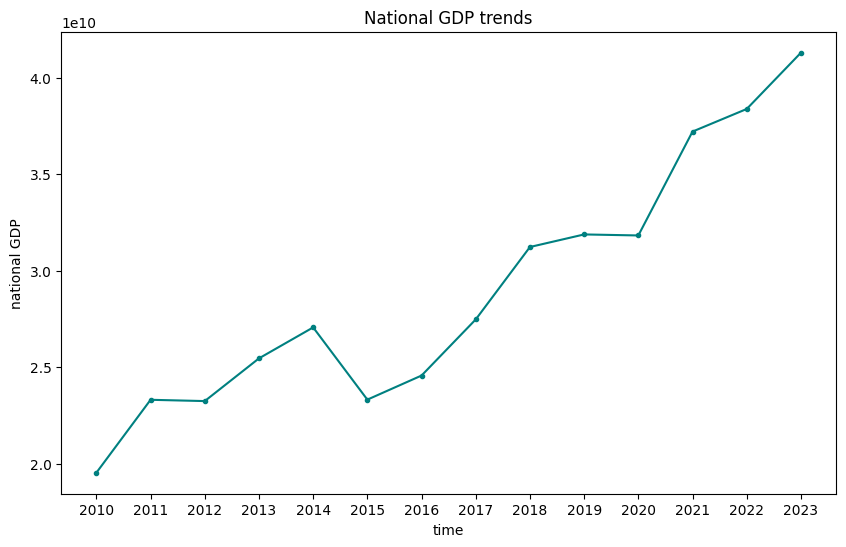

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('National GDP trends')
plt.xlabel('time')
plt.ylabel('national GDP')

plt.plot(file['Year'],file['NationalGDP'],marker='.', color='teal')

In [ ]:
x=dt4training1.loc[:,'time']
x=sm.add_constant(x)

y=dt4training1.loc[:,'NationalGDP']

model1=sm.OLS(y,x).fit()
model1.params

,0
const,19643301459.13
time,1102357174.65


In [ ]:
#time series forcasting

x_test = dt4testing1.loc[:,'time']
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
427,32871587554.87
465,33973944729.52
503,35076301904.16


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v1_assess = dt4testing1.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v1_assess['predict_nationalGDP']=model1.predict(x_test)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v1_assess['percentage_error']= abs( (model_v1_assess['NationalGDP']-model_v1_assess['predict_nationalGDP'])/model_v1_assess['NationalGDP'] )


display(model_v1_assess)

,Year,NationalGDP,time,predict_nationalGDP,percentage_error
427,2021,37204563051.00,12,32871587554.87,0.12
465,2022,38376046175.00,13,33973944729.52,0.11
503,2023,41291245222.00,14,35076301904.16,0.15


In [ ]:
model_v1_assess['percentage_error'].mean()

np.float64(0.1272293198101764)

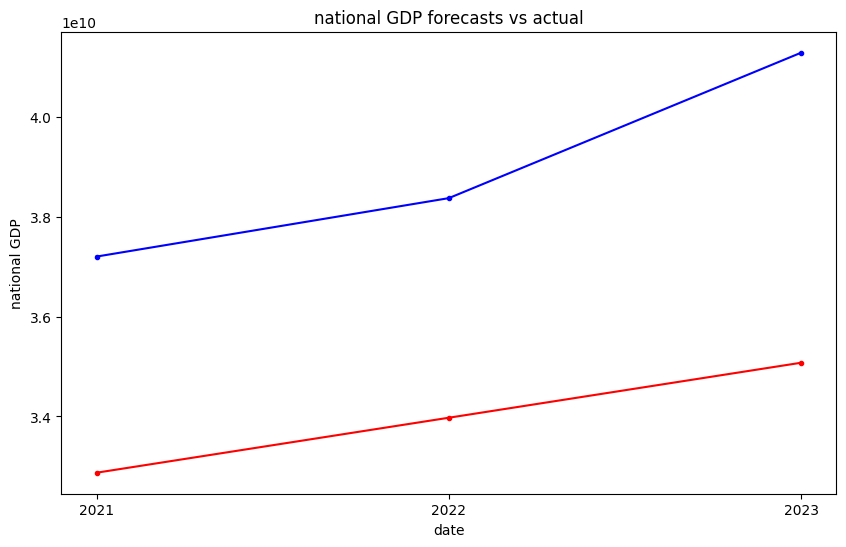

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('national GDP forecasts vs actual')
plt.xlabel('date')
plt.ylabel('national GDP')

plt.plot(model_v1_assess['Year'],model_v1_assess['NationalGDP'],marker='.', color = "blue")
plt.plot(model_v1_assess['Year'],model_v1_assess['predict_nationalGDP'],marker='.', color = 'red')

##total labour force

In [ ]:
#to make training and testing dataframes
dt4training2=file.loc[(file['Year'].isin(yearsTrain)),['Year','TotalLabourForce','time']]
dt4testing2=file.loc[(file['Year'].isin(yearsTest)),['Year','TotalLabourForce','time']]

display(dt4training2)
display(dt4testing2)

,Year,TotalLabourForce,time
9,2010,681602.00,1
47,2011,687096.00,2
85,2012,683224.00,3
123,2013,679674.00,4
161,2014,674311.00,5
199,2015,684582.00,6
237,2016,691057.00,7
275,2017,700101.00,8
313,2018,703757.00,9
351,2019,703304.00,10


,Year,TotalLabourForce,time
427,2021,703723.00,12
465,2022,736004.00,13
503,2023,757348.00,14


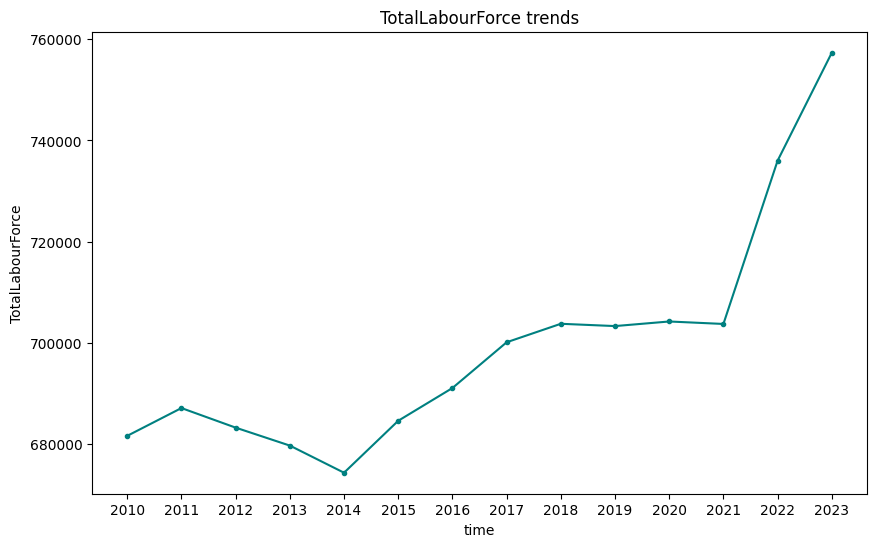

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('TotalLabourForce trends')
plt.xlabel('time')
plt.ylabel('TotalLabourForce')

plt.plot(file['Year'],file['TotalLabourForce'],marker='.', color='teal')

In [ ]:
x=dt4training2.loc[:,'time']
x=sm.add_constant(x)

y=dt4training2.loc[:,'TotalLabourForce']

model2=sm.OLS(y,x).fit()
model2.params

,0
const,674061.22
time,2700.69


In [ ]:
#time series forcasting

x_test2 = dt4testing2.loc[:,'time']
x_test2 = sm.add_constant(x_test2)

model2.predict(x_test2)

,0
427,706469.51
465,709170.20
503,711870.89


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v2_assess = dt4testing2.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v2_assess['predict_TotalLabourForce']=model2.predict(x_test2)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v2_assess['percentage_error']= abs( (model_v2_assess['TotalLabourForce']-model_v2_assess['predict_TotalLabourForce'])/model_v2_assess['TotalLabourForce'] )


display(model_v2_assess)

,Year,TotalLabourForce,time,predict_TotalLabourForce,percentage_error
427,2021,703723.00,12,706469.51,0.00
465,2022,736004.00,13,709170.20,0.04
503,2023,757348.00,14,711870.89,0.06


In [ ]:
model_v2_assess['percentage_error'].mean()

np.float64(0.033469810993046446)

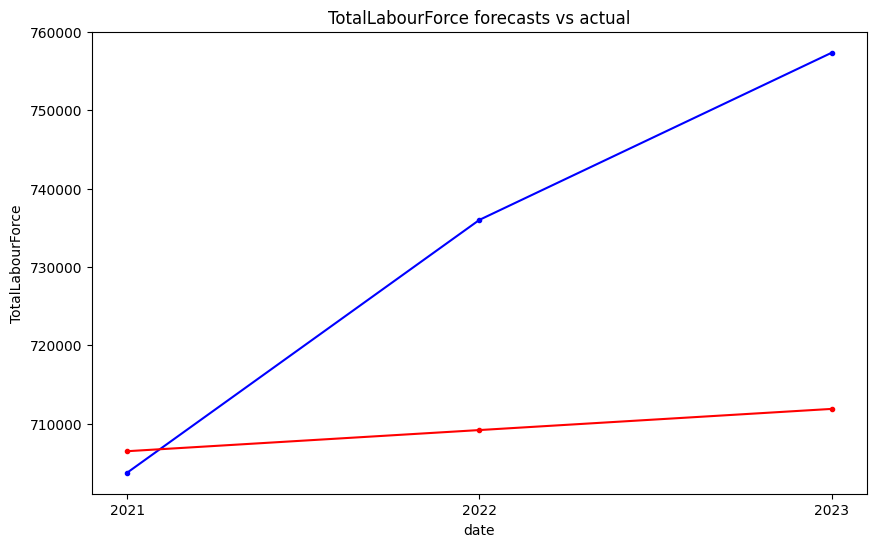

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('TotalLabourForce forecasts vs actual')
plt.xlabel('date')
plt.ylabel('TotalLabourForce')

plt.plot(model_v2_assess['Year'],model_v2_assess['TotalLabourForce'],marker='.', color = "blue")
plt.plot(model_v2_assess['Year'],model_v2_assess['predict_TotalLabourForce'],marker='.', color = 'red')

##urban proportion

In [ ]:
#to make training and testing dataframes
dt4training3=file.loc[(file['Year'].isin(yearsTrain)),['Year','UrbanProportion','time']]
dt4testing3=file.loc[(file['Year'].isin(yearsTest)),['Year','UrbanProportion','time']]

display(dt4training3)
display(dt4testing3)

,Year,UrbanProportion,time
9,2010,68.09,1
47,2011,67.97,2
85,2012,67.97,3
123,2013,68.12,4
161,2014,68.27,5
199,2015,68.42,6
237,2016,68.56,7
275,2017,68.72,8
313,2018,68.88,9
351,2019,69.05,10


,Year,UrbanProportion,time
427,2021,69.42,12
465,2022,69.61,13
503,2023,69.81,14


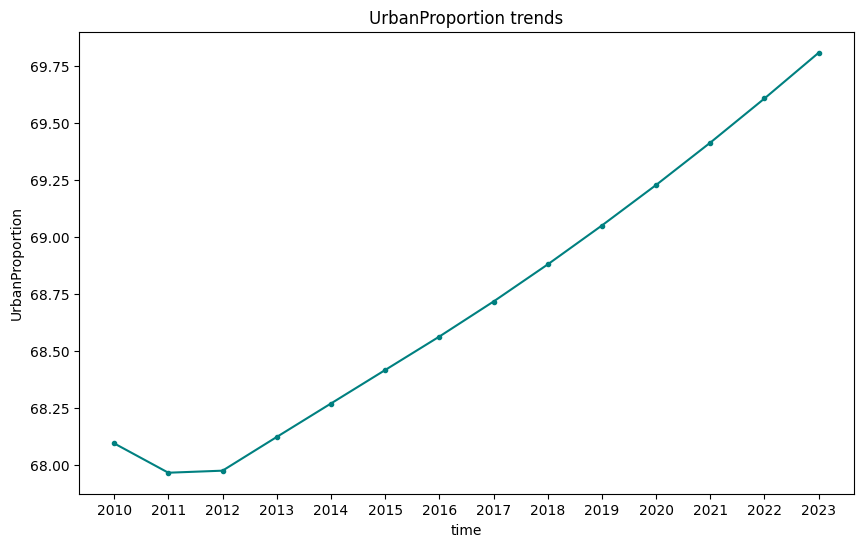

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('UrbanProportion trends')
plt.xlabel('time')
plt.ylabel('UrbanProportion')

plt.plot(file['Year'],file['UrbanProportion'],marker='.', color='teal')

In [ ]:
x=dt4training3.loc[:,'time']
x=sm.add_constant(x)

y=dt4training3.loc[:,'UrbanProportion']

model3=sm.OLS(y,x).fit()
model3.params

,0
const,67.70
time,0.13


In [ ]:
#time series forcasting

x_test3 = dt4testing3.loc[:,'time']
x_test3 = sm.add_constant(x_test3)

model3.predict(x_test3)

,0
427,69.26
465,69.38
503,69.51


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v3_assess = dt4testing3.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v3_assess['predict_UrbanProportion']=model3.predict(x_test3)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v3_assess['percentage_error']= abs( (model_v3_assess['UrbanProportion']-model_v3_assess['predict_UrbanProportion'])/model_v3_assess['UrbanProportion'] )


display(model_v3_assess)

,Year,UrbanProportion,time,predict_UrbanProportion,percentage_error
427,2021,69.42,12,69.26,0.00
465,2022,69.61,13,69.38,0.00
503,2023,69.81,14,69.51,0.00


In [ ]:
model_v3_assess['percentage_error'].mean()

np.float64(0.003249941480807452)

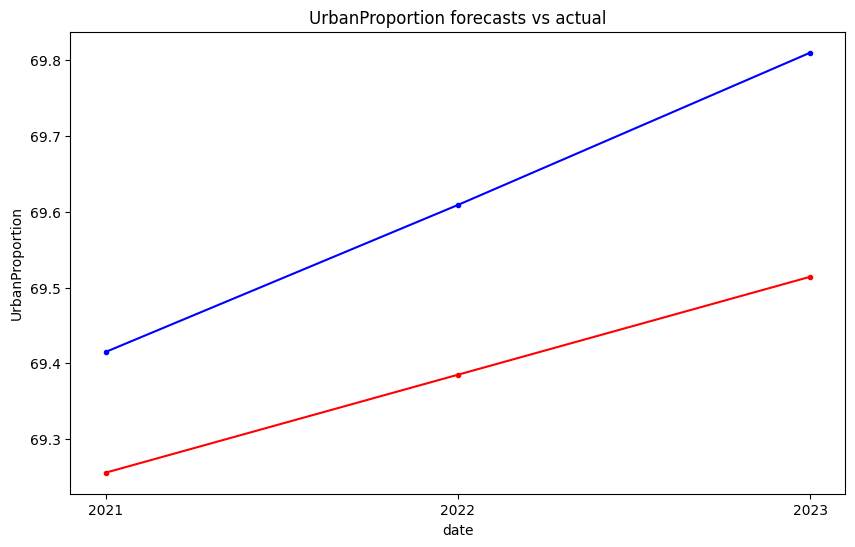

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('UrbanProportion forecasts vs actual')
plt.xlabel('date')
plt.ylabel('UrbanProportion')

plt.plot(model_v3_assess['Year'],model_v3_assess['UrbanProportion'],marker='.', color = "blue")
plt.plot(model_v3_assess['Year'],model_v3_assess['predict_UrbanProportion'],marker='.', color = 'red')

##population growth

In [ ]:
#to make training and testing dataframes
dt4training4=file.loc[(file['Year'].isin(yearsTrain)),['Year','PopGrow','time']]
dt4testing4=file.loc[(file['Year'].isin(yearsTest)),['Year','PopGrow','time']]

display(dt4training4)
display(dt4testing4)

,Year,PopGrow,time
9,2010,-0.23,1
47,2011,-0.30,2
85,2012,-0.36,3
123,2013,-0.36,4
161,2014,-0.26,5
199,2015,0.07,6
237,2016,0.03,7
275,2017,0.12,8
313,2018,0.35,9
351,2019,0.37,10


,Year,PopGrow,time
427,2021,0.11,12
465,2022,1.34,13
503,2023,1.58,14


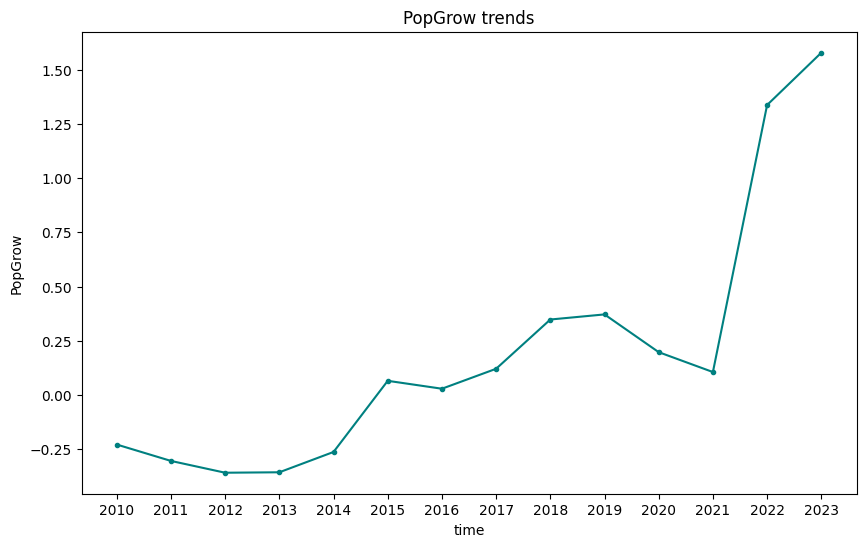

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('PopGrow trends')
plt.xlabel('time')
plt.ylabel('PopGrow')

plt.plot(file['Year'],file['PopGrow'],marker='.', color='teal')

In [ ]:
x=dt4training4.loc[:,'time']
x=sm.add_constant(x)

y=dt4training4.loc[:,'PopGrow']

model4=sm.OLS(y,x).fit()
model4.params

,0
const,-0.48
time,0.07


In [ ]:
#time series forcasting

x_test4 = dt4testing4.loc[:,'time']
x_test4 = sm.add_constant(x_test4)

model4.predict(x_test4)

,0
427,0.41
465,0.49
503,0.56


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v4_assess = dt4testing4.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v4_assess['predict_PopGrow']=model4.predict(x_test4)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v4_assess['percentage_error']= abs( (model_v4_assess['PopGrow']-model_v4_assess['predict_PopGrow'])/model_v4_assess['PopGrow'] )


display(model_v4_assess)

,Year,PopGrow,time,predict_PopGrow,percentage_error
427,2021,0.11,12,0.41,2.89
465,2022,1.34,13,0.49,0.64
503,2023,1.58,14,0.56,0.64


In [ ]:
model_v4_assess['percentage_error'].mean()

np.float64(1.3911301357769688)

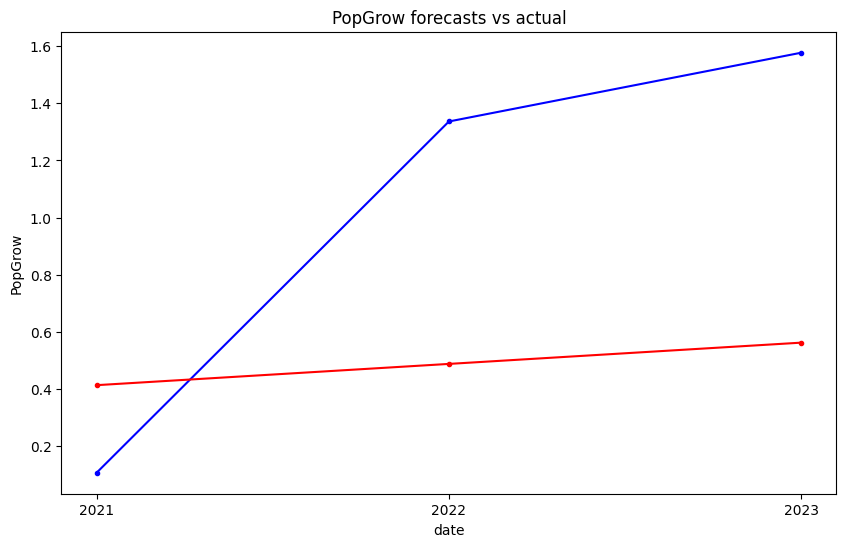

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('PopGrow forecasts vs actual')
plt.xlabel('date')
plt.ylabel('PopGrow')

plt.plot(model_v4_assess['Year'],model_v4_assess['PopGrow'],marker='.', color = "blue")
plt.plot(model_v4_assess['Year'],model_v4_assess['predict_PopGrow'],marker='.', color = 'red')

##debt to GDP

In [ ]:
#to make training and testing dataframes
dt4training5=file.loc[(file['Year'].isin(yearsTrain)),['Year','Debt_GDP','time']]
dt4testing5=file.loc[(file['Year'].isin(yearsTest)),['Year','Debt_GDP','time']]

display(dt4training5)
display(dt4testing5)

,Year,Debt_GDP,time
9,2010,3.36,1
47,2011,3.29,2
85,2012,10.91,3
123,2013,11.06,4
161,2014,11.32,5
199,2015,10.98,6
237,2016,10.93,7
275,2017,10.00,8
313,2018,9.32,9
351,2019,9.71,10


,Year,Debt_GDP,time
427,2021,17.85,12
465,2022,18.92,13
503,2023,19.99,14


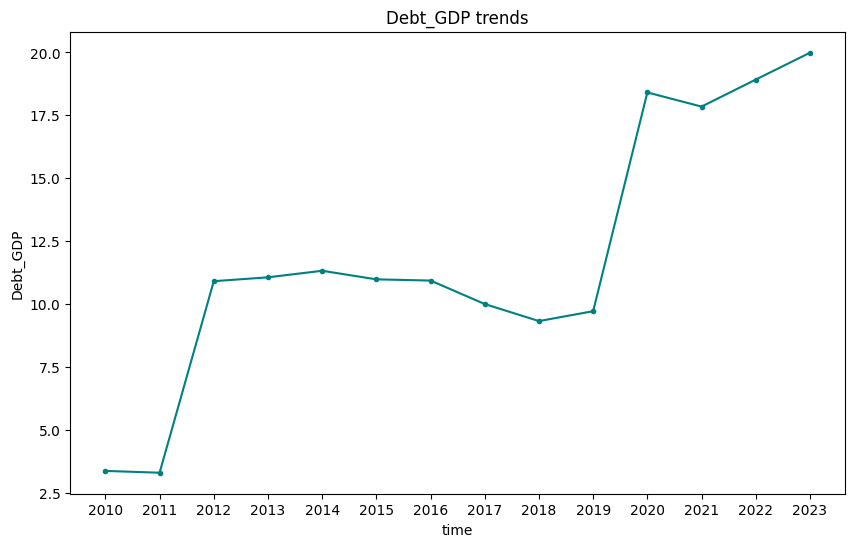

In [ ]:
#visualization initial
plt.figure(figsize=(10,6))

plt.title('Debt_GDP trends')
plt.xlabel('time')
plt.ylabel('Debt_GDP')

plt.plot(file['Year'],file['Debt_GDP'],marker='.', color='teal')

In [ ]:
x=dt4training5.loc[:,'time']
x=sm.add_constant(x)

y=dt4training5.loc[:,'Debt_GDP']

model5=sm.OLS(y,x).fit()
model5.params

,0
const,4.83
time,0.85


In [ ]:
#time series forcasting

x_test5 = dt4testing5.loc[:,'time']
x_test5 = sm.add_constant(x_test5)

model5.predict(x_test5)

,0
427,15.04
465,15.89
503,16.75


In [ ]:
# final compare predicted to actual
# MAPE Score
# mean absolute percentage error

# step 1: copy testing data to new dataframe
# never want to mess with original or testing data

model_v5_assess = dt4testing5.copy()

# next add column with predicted revenue numbers to see alongside actuals
model_v5_assess['predict_Debt_GDP']=model5.predict(x_test5)

# see the difference according to MAPE
# find percentage error of each row and then find the mean of that
model_v5_assess['percentage_error']= abs( (model_v5_assess['Debt_GDP']-model_v5_assess['predict_Debt_GDP'])/model_v5_assess['Debt_GDP'] )


display(model_v5_assess)

,Year,Debt_GDP,time,predict_Debt_GDP,percentage_error
427,2021,17.85,12,15.04,0.16
465,2022,18.92,13,15.89,0.16
503,2023,19.99,14,16.75,0.16


In [ ]:
model_v5_assess['percentage_error'].mean()

np.float64(0.15973613643322218)

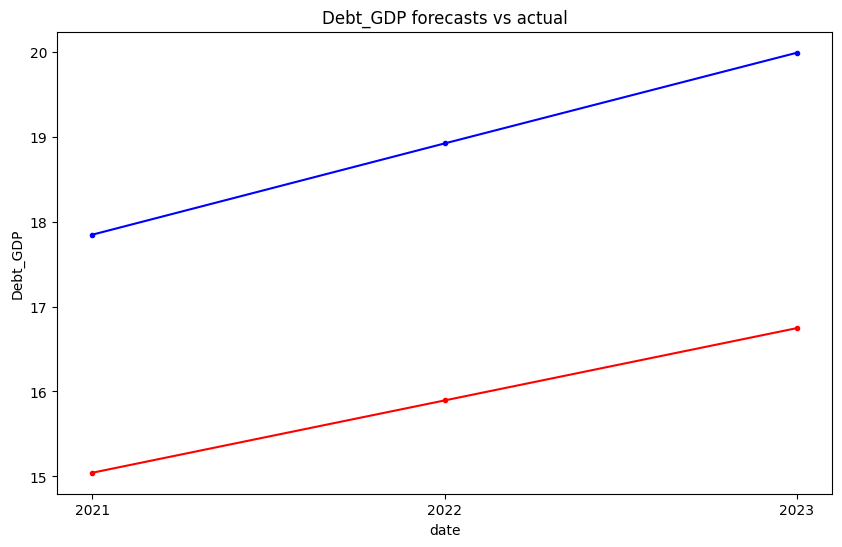

In [ ]:
# visualize both

plt.figure(figsize=(10,6))

plt.title('Debt_GDP forecasts vs actual')
plt.xlabel('date')
plt.ylabel('Debt_GDP')

plt.plot(model_v5_assess['Year'],model_v5_assess['Debt_GDP'],marker='.', color = "blue")
plt.plot(model_v5_assess['Year'],model_v5_assess['predict_Debt_GDP'],marker='.', color = 'red')